In [ ]:
import sys
!{sys.executable} -m pip install pandas scikit-learn matplotlib seaborn

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB
None
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    2.158416  131.689769  246.6930

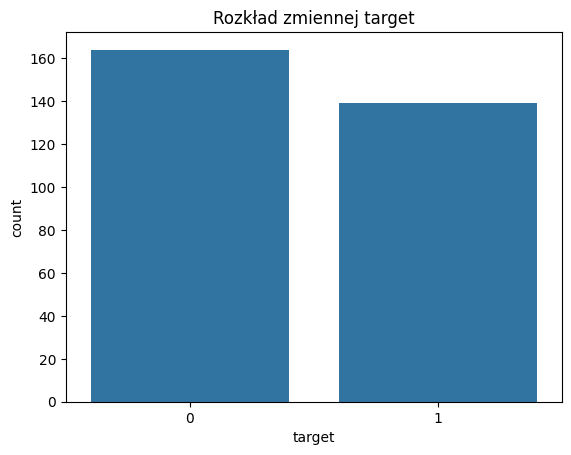

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

df = pd.read_csv('Heart_disease_cleveland_new.csv')

print(df.info())
print(df.describe())

sns.countplot(x='target', data=df)
plt.title('Rozkład zmiennej target')
plt.show()

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


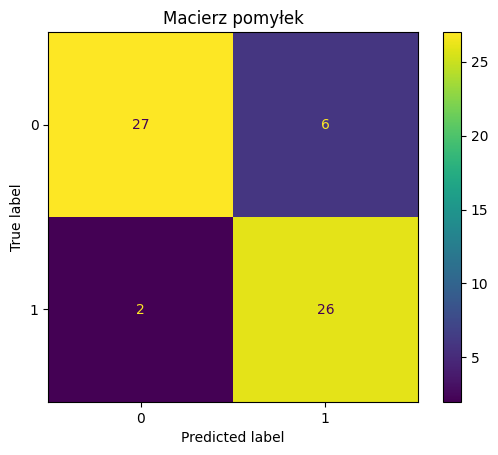

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



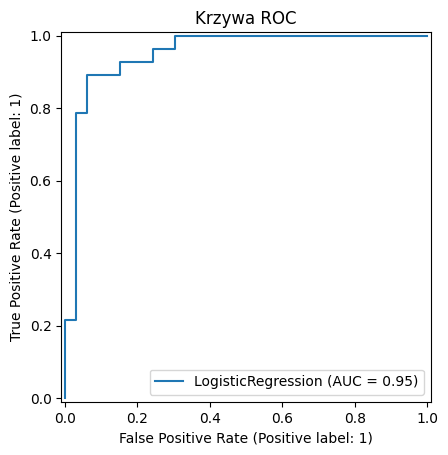

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Macierz pomyłek")
plt.show()

print(classification_report(y_test, y_pred))

RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("Krzywa ROC")
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

model_std = LogisticRegression(max_iter=1000)
model_std.fit(X_train_std, y_train)
print("Wynik na danych standaryzowanych (Accuracy):", model_std.score(X_test_std, y_test))

scaler_minmax = MinMaxScaler()
X_train_norm = scaler_minmax.fit_transform(X_train)
X_test_norm = scaler_minmax.transform(X_test)

model_norm = LogisticRegression(max_iter=1000)
model_norm.fit(X_train_norm, y_train)
print("Wynik na danych znormalizowanych (Accuracy):", model_norm.score(X_test_norm, y_test))

Wynik na danych standaryzowanych (Accuracy): 0.8688524590163934
Wynik na danych znormalizowanych (Accuracy): 0.8524590163934426


In [12]:
C_values = [0.01, 0.1, 1, 10, 100]
l1_ratios = [0.0, 0.5, 1.0]

wyniki = []

for c in C_values:
    for l1 in l1_ratios:
        clf = LogisticRegression(solver='saga', C=c, l1_ratio=l1, max_iter=2000)
        clf.fit(X_train_std, y_train)
        
        train_acc = clf.score(X_train_std, y_train)
        test_acc = clf.score(X_test_std, y_test)
        
        wyniki.append({'C': c, 'l1_ratio': l1, 'Train Acc': train_acc, 'Test Acc': test_acc})

df_wyniki = pd.DataFrame(wyniki)
print(df_wyniki)

         C  l1_ratio  Train Acc  Test Acc
0     0.01       0.0   0.842975  0.885246
1     0.01       0.5   0.710744  0.721311
2     0.01       1.0   0.541322  0.540984
3     0.10       0.0   0.842975  0.868852
4     0.10       0.5   0.838843  0.852459
5     0.10       1.0   0.851240  0.852459
6     1.00       0.0   0.855372  0.868852
7     1.00       0.5   0.855372  0.868852
8     1.00       1.0   0.851240  0.868852
9    10.00       0.0   0.855372  0.868852
10   10.00       0.5   0.855372  0.868852
11   10.00       1.0   0.855372  0.868852
12  100.00       0.0   0.855372  0.868852
13  100.00       0.5   0.855372  0.868852
14  100.00       1.0   0.855372  0.868852


   Folds  KFold_Mean  KFold_Std  Stratified_Mean  Stratified_Std
0      2    0.805785   0.028926         0.838843        0.004132
1      5    0.801276   0.071257         0.830442        0.024782
2     10    0.822000   0.075162         0.818333        0.048155


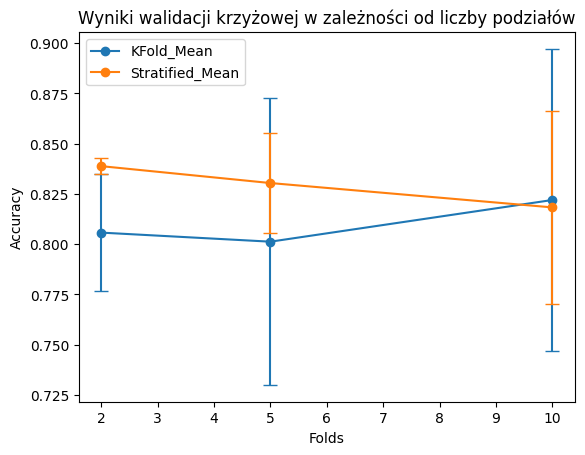

In [ ]:
from sklearn.model_selection import cross_val_score, KFold, StratifiedKFold
import numpy as np

folds = [2, 5, 10]
cv_results = []

for k in folds:
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    scores_kfold = cross_val_score(model_std, X_train_std, y_train, cv=kf, scoring='accuracy')
    
    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    scores_stratified = cross_val_score(model_std, X_train_std, y_train, cv=skf, scoring='accuracy')
    
    cv_results.append({
        'Folds': k,
        'KFold_Mean': np.mean(scores_kfold),
        'KFold_Std': np.std(scores_kfold),
        'Stratified_Mean': np.mean(scores_stratified),
        'Stratified_Std': np.std(scores_stratified)
    })

df_cv = pd.DataFrame(cv_results)
print(df_cv)

df_cv.plot(x='Folds', y=['KFold_Mean', 'Stratified_Mean'], marker='o', yerr=df_cv[['KFold_Std', 'Stratified_Std']].values.T, capsize=5)
plt.title('Wyniki walidacji krzyżowej w zależności od liczby podziałów')
plt.ylabel('Accuracy')
plt.show()